* This notebook models the NASDAQ (^IXIC) daily closing index using an ARIMA approach.
  
* The series is transformed to stationarity, the model order is selected using information criteria, and forecasts with confidence intervals are produced. 

In [17]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

In [19]:
df = pd.read_csv("../data/ixic.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

y = df["^IXIC"].astype(float).sort_index()
y.name = "ixic_close"

print("Series type:", type(y))
print("Start:", y.index.min().date(), "End:", y.index.max().date())
print("Observations:", len(y))
print("Missing:", int(y.isna().sum()))
print("Weekend rows:", int((y.index.dayofweek >= 5).sum()))

Series type: <class 'pandas.core.series.Series'>
Start: 2016-01-04 End: 2026-02-20
Observations: 2548
Missing: 0
Weekend rows: 0


In [21]:
y_log = np.log(y)

In [23]:
best_aic = np.inf
best_order = None
best_fit = None

d = 1
p_values = range(0, 3)
q_values = range(0, 3)

print("AIC grid search for ARIMA(p,1,q):")
for p in p_values:
    for q in q_values:
        try:
            fit = ARIMA(y_log, order=(p, d, q)).fit()

            # skip non-converged solutions
            if hasattr(fit, "mle_retvals") and not fit.mle_retvals.get("converged", True):
                print(f"ARIMA({p},{d},{q}) NOT CONVERGED")
                continue

            aic = float(fit.aic)
            print(f"ARIMA({p},{d},{q}) AIC = {aic:.2f}")

            if aic < best_aic:
                best_aic = aic
                best_order = (p, d, q)
                best_fit = fit

        except Exception:
            print(f"ARIMA({p},{d},{q}) FAILED")

print("\nChosen model:", best_order, "with AIC =", round(best_aic, 2))

AIC grid search for ARIMA(p,1,q):
ARIMA(0,1,0) NOT CONVERGED
ARIMA(0,1,1) AIC = -14594.17
ARIMA(0,1,2) AIC = -14601.96
ARIMA(1,1,0) AIC = -14598.24
ARIMA(1,1,1) AIC = -14601.00
ARIMA(1,1,2) AIC = -14601.76
ARIMA(2,1,0) AIC = -14603.52
ARIMA(2,1,1) AIC = -14600.48
ARIMA(2,1,2) AIC = -14599.04

Chosen model: (2, 1, 0) with AIC = -14603.52


In [25]:
resid = best_fit.resid
lb = acorr_ljungbox(resid, lags=[10], return_df=True)

print("\nLjung–Box test (lag 10):")
print(lb)


Ljung–Box test (lag 10):
     lb_stat  lb_pvalue
10  0.107537        1.0


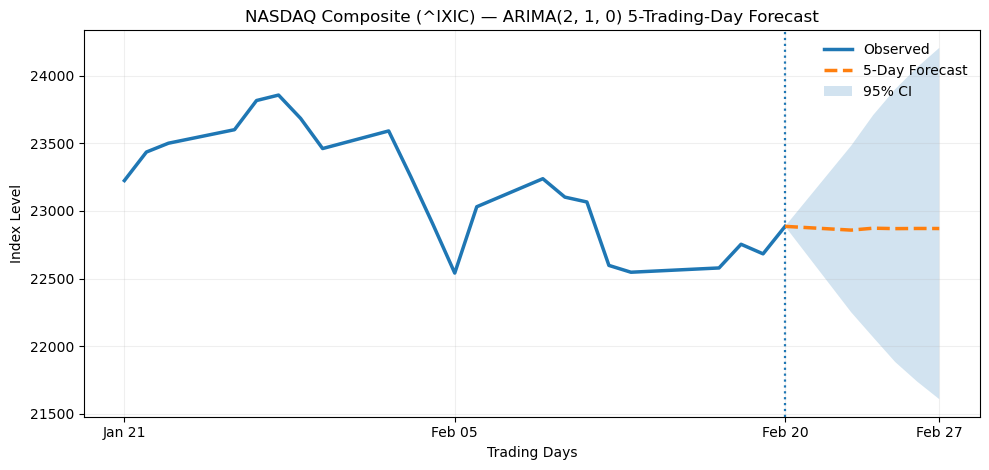

Last observed date: Feb 20
Forecast: Feb 23, Feb 24, Feb 25, Feb 26, Feb 27


In [27]:
H = 5
window = 22

hist = y.iloc[-window:]
last_date = hist.index[-1]   

fc_res = best_fit.get_forecast(steps=H)
mean_log = fc_res.predicted_mean
ci_log = fc_res.conf_int(alpha=0.05)

mean_fc = np.exp(mean_log).values
lower_fc = np.exp(ci_log.iloc[:, 0]).values
upper_fc = np.exp(ci_log.iloc[:, 1]).values

future_dates = pd.bdate_range(start=last_date, periods=H + 1)[1:]

forecast_5d = pd.Series(mean_fc, index=future_dates, name="ARIMA_forecast")
ci_lower = pd.Series(lower_fc, index=future_dates, name="Lower_95")
ci_upper = pd.Series(upper_fc, index=future_dates, name="Upper_95")

x_fc = pd.DatetimeIndex([last_date]).append(future_dates)
y_fc = np.r_[hist.iloc[-1], forecast_5d.values]

ci_lower_conn = np.r_[hist.iloc[-1], ci_lower.values]
ci_upper_conn = np.r_[hist.iloc[-1], ci_upper.values]

tick_dates = pd.to_datetime(sorted(set([
    hist.index[0],                          # left edge
    hist.index[len(hist)//2],               # middle-ish
    last_date,                              # Feb 20 (last observed)
    future_dates[-1],                       # Feb 27 (last forecast)
])))


plt.figure(figsize=(10, 4.8))
plt.plot(hist.index, hist.values, linewidth=2.5, label="Observed")
plt.axvline(last_date, linestyle=":", linewidth=1.6)
plt.plot(x_fc, y_fc, linestyle="--", linewidth=2.5, label=f"{H}-Day Forecast")
plt.fill_between(x_fc, ci_lower_conn, ci_upper_conn, alpha=0.2, label="95% CI")
plt.title(f"NASDAQ Composite (^IXIC) — ARIMA{best_order} {H}-Trading-Day Forecast")
plt.xlabel("Trading Days")
plt.ylabel("Index Level")
ax = plt.gca()
ax.set_xticks(tick_dates)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=0)
plt.grid(True, alpha=0.2)
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

print("Last observed date:", last_date.strftime("%b %d"))
print("Forecast:", ", ".join(d.strftime("%b %d") for d in future_dates))

In [29]:
forecast_table = pd.DataFrame({
    "Forecast (mean)": forecast_5d.round(2),
    "Lower 95% CI": ci_lower.round(2),
    "Upper 95% CI": ci_upper.round(2),
})

forecast_table.index.name = "Date"
forecast_table

,Forecast (mean),Lower 95% CI,Upper 95% CI
Date,,,
2026-02-23,22858.31,22250.66,23482.55
2026-02-24,22872.47,22065.08,23709.40
2026-02-25,22869.33,21882.28,23900.89
2026-02-26,22870.45,21737.33,24062.64
2026-02-27,22870.15,21607.58,24206.50


* The AIC procedure selected an ARIMA(2,1,0) model for the log-transformed NASDAQ index.
* The Ljung–Box test (p-value ≈ 1.0) indicates no remaining autocorrelation in the residuals, meaning the model adequately captures the time-series dynamics.
* The 5-trading-day forecast projects a relatively stable index level with small day-to-day changes, while the 95% confidence interval widens over the horizon, reflecting increasing uncertainty farther into the future.